In [1]:
# === ABLACION: sin features con F1 individual > 0.9 (data leakage, umbral 0.9) ===
# NSL-KDD: sin src_bytes, dst_bytes | Mirai: sin avg_pkt_size | DS2OS: sin cambios
import os as _os
_os.makedirs(str(Path.cwd().parent / "figuras_sinleak"), exist_ok=True)
_os.chdir(str(Path.cwd().parent / "figuras_sinleak"))
print('Salidas relativas (figuras/JSON-relativos) -> C:/Users/user/TFM/figuras_sinleak')

# imports y configuración global

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path

# Preprocesamiento (mismo que réplicas anteriores)
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_selection import VarianceThreshold

# Métricas (mismas que réplicas anteriores)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, roc_auc_score,
    precision_score, recall_score
)

# EBM — el modelo principal
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show

# Visualización
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

# Semilla global — igual que en todas las réplicas
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('Librerías cargadas correctamente.')
print(f'Semilla global: {RANDOM_SEED}')

# Cacheo de modelos EBM - entrena la 1a vez, recarga despues
import joblib
MODELOS_DIR = (Path.cwd().parent / "modelos")
MODELOS_DIR.mkdir(parents=True, exist_ok=True)

def get_or_train_ebm(modelo, X_tr, y_tr, nombre_fichero):
    ruta = MODELOS_DIR / nombre_fichero
    if ruta.exists():
        print(f'Recargando EBM cacheado: {ruta.name}')
        return joblib.load(ruta)
    print(f'Entrenando EBM (no cacheado): {ruta.name} ...')
    modelo.fit(X_tr, y_tr)
    joblib.dump(modelo, ruta)
    print(f'EBM guardado en: {ruta}')
    return modelo


Salidas relativas (figuras/JSON-relativos) -> C:/Users/user/TFM/figuras_sinleak


Librerías cargadas correctamente.
Semilla global: 42


---
## DATASET 1 — NSL-KDD


In [2]:
# mismo preprocesado que Clasificadores NSL-KDD.ipynb (8 features IG>0.40, LabelEncoder, split 80/20 + MinMaxScaler)

COL_NAMES = [
    'duration','protocol_type','service','flag',
    'src_bytes','dst_bytes','land','wrong_fragment','urgent','hot',
    'num_failed_logins','logged_in','num_compromised','root_shell',
    'su_attempted','num_root','num_file_creations','num_shells',
    'num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate',
    'srv_serror_rate','rerror_rate','srv_rerror_rate',
    'same_srv_rate','diff_srv_rate','srv_diff_host_rate',
    'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate',
    'dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate',
    'dst_host_srv_rerror_rate','label','difficulty'
]

# 8 features con Information Gain > 0.40 (Aljawarneh 2018, Tabla 4)
SELECTED_FEATURES = [
    'service', 'flag',
    'diff_srv_rate', 'same_srv_rate', 'dst_host_srv_count', 'dst_host_same_srv_rate',
]
FEATURE_COLS_NSL = SELECTED_FEATURES

CLASS_NAMES_NSL = {1: 'Normal', 2: 'DoS', 3: 'Probe', 4: 'R2L', 5: 'U2R'}

DOS   = {'back','land','neptune','pod','smurf','teardrop',
         'apache2','udpstorm','processtable','mailbomb'}
PROBE = {'ipsweep','nmap','portsweep','satan','mscan','saint'}
R2L   = {'ftp_write','guess_passwd','imap','multihop','phf','spy',
         'warezclient','warezmaster','sendmail','named',
         'snmpgetattack','snmpguess','xlock','xsnoop','worm'}
U2R   = {'buffer_overflow','loadmodule','perl','rootkit',
         'httptunnel','ps','sqlattack','xterm'}

def map_label_nsl(label):
    label = label.lower().strip()
    if label == 'normal': return 1
    if label in DOS:      return 2
    if label in PROBE:    return 3
    if label in R2L:      return 4
    if label in U2R:      return 5
    return 2  # ataque no catalogado → DoS

SEARCH_PATHS_NSL = [
    (Path.home() / ".cache" / "kagglehub" / "datasets" / "hassan06" / "nslkdd" / "versions" / "1" / "KDDTrain+_20Percent.txt"),
    Path("KDDTrain+_20Percent.txt"),
    Path.home() / "Downloads" / "KDDTrain+_20Percent.txt",
]

ruta_nsl = next((p for p in SEARCH_PATHS_NSL if p.exists()), None)
if ruta_nsl is None:
    raise FileNotFoundError("No se encontró KDDTrain+_20Percent.txt")

df_nsl = pd.read_csv(ruta_nsl, header=None, names=COL_NAMES).drop(columns=['difficulty'])

# Encoding categóricas
protocol_map = {'tcp': 1, 'udp': 2, 'icmp': 3}
df_nsl['protocol_type'] = df_nsl['protocol_type'].str.lower().map(protocol_map).fillna(0)
df_nsl['service'] = LabelEncoder().fit_transform(df_nsl['service'].astype(str))
df_nsl['flag']    = LabelEncoder().fit_transform(df_nsl['flag'].astype(str))

# Etiquetas multiclase (1–5) y binaria (0/1)
y_multi = df_nsl['label'].apply(map_label_nsl).values
y_bin   = (y_multi > 1).astype(int)  # 1=Normal → 0, resto → 1

X_nsl = df_nsl[SELECTED_FEATURES].values.astype(np.float32)

# Split 80/20 estratificado
X_tr, X_te, y_tr_multi, y_te_multi, y_tr_bin, y_te_bin = train_test_split(
    X_nsl, y_multi, y_bin,
    test_size=0.20, random_state=RANDOM_SEED, stratify=y_multi
)

# MinMaxScaler post-split
scaler_nsl = MinMaxScaler()
X_tr_nsl = scaler_nsl.fit_transform(X_tr)
X_te_nsl = scaler_nsl.transform(X_te)

print(f"NSL-KDD cargado: {len(df_nsl):,} instancias")
print(f"Features: {len(SELECTED_FEATURES)} | Train: {len(X_tr_nsl):,} | Test: {len(X_te_nsl):,}")
print(f"\n{'Clase':<10} {'Total':>8} {'Train':>8}  {'Test':>6}")
for c, name in CLASS_NAMES_NSL.items():
    print(f"  {name:<8} {(y_multi==c).sum():>8,} {(y_tr_multi==c).sum():>8,}  {(y_te_multi==c).sum():>6,}")


NSL-KDD cargado: 25,192 instancias
Features: 6 | Train: 20,153 | Test: 5,039

Clase         Total    Train    Test
  Normal     13,449   10,759   2,690
  DoS         9,234    7,387   1,847
  Probe       2,289    1,831     458
  R2L           209      167      42
  U2R            11        9       2


In [3]:
# evaluar_modelo + EBM multiclase

def evaluar_modelo(model, X_test, y_test, nombre_dataset, nombre_modelo='EBM'):
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='macro', zero_division=0)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='macro', zero_division=0)
    n_clases = len(np.unique(y_test))
    if n_clases == 2:
        auc = roc_auc_score(y_test, y_proba[:, 1])
    else:
        auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
    W = 60
    print('=' * W)
    print(f' {nombre_modelo} — {nombre_dataset}'.center(W))
    print('=' * W)
    print(f'  Accuracy   : {acc:.4f}')
    print(f'  Precision  : {prec:.4f}  (macro)')
    print(f'  Recall     : {rec:.4f}  (macro)')
    print(f'  F1-Score   : {f1:.4f}  (macro)')
    print(f'  AUC-ROC    : {auc:.4f}')
    print('-' * W)
    print(classification_report(y_test, y_pred, zero_division=0))
    return {'dataset': nombre_dataset, 'accuracy': acc,
            'precision': prec, 'recall': rec,
            'f1_macro': f1, 'auc': auc}

CLASS_NAMES_NSL_LIST = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']

ebm_nsl_multi = ExplainableBoostingClassifier(
    max_bins         = 256,
    interactions     = 10,
    learning_rate    = 0.01,
    max_rounds       = 5000,
    min_samples_leaf = 2,
    random_state     = RANDOM_SEED,
    feature_names    = FEATURE_COLS_NSL,
)

ebm_nsl_multi = get_or_train_ebm(ebm_nsl_multi, X_tr_nsl, y_tr_multi, 'ebm_nslkdd_xai_sinleak.joblib')

resultados_nsl_multi = evaluar_modelo(
    ebm_nsl_multi, X_te_nsl, y_te_multi,
    nombre_dataset='NSL-KDD'
)


Entrenando EBM (no cacheado): ebm_nslkdd_xai_sinleak.joblib ...


EBM guardado en: C:\Users\user\TFM\modelos\ebm_nslkdd_xai_sinleak.joblib
                        EBM — NSL-KDD                       
  Accuracy   : 0.9732
  Precision  : 0.8390  (macro)
  Recall     : 0.7936  (macro)
  F1-Score   : 0.8125  (macro)
  AUC-ROC    : 0.9505
------------------------------------------------------------
              precision    recall  f1-score   support

           1       0.97      0.99      0.98      2690
           2       0.99      0.97      0.98      1847
           3       0.93      0.94      0.94       458
           4       0.80      0.57      0.67        42
           5       0.50      0.50      0.50         2

    accuracy                           0.97      5039
   macro avg       0.84      0.79      0.81      5039
weighted avg       0.97      0.97      0.97      5039



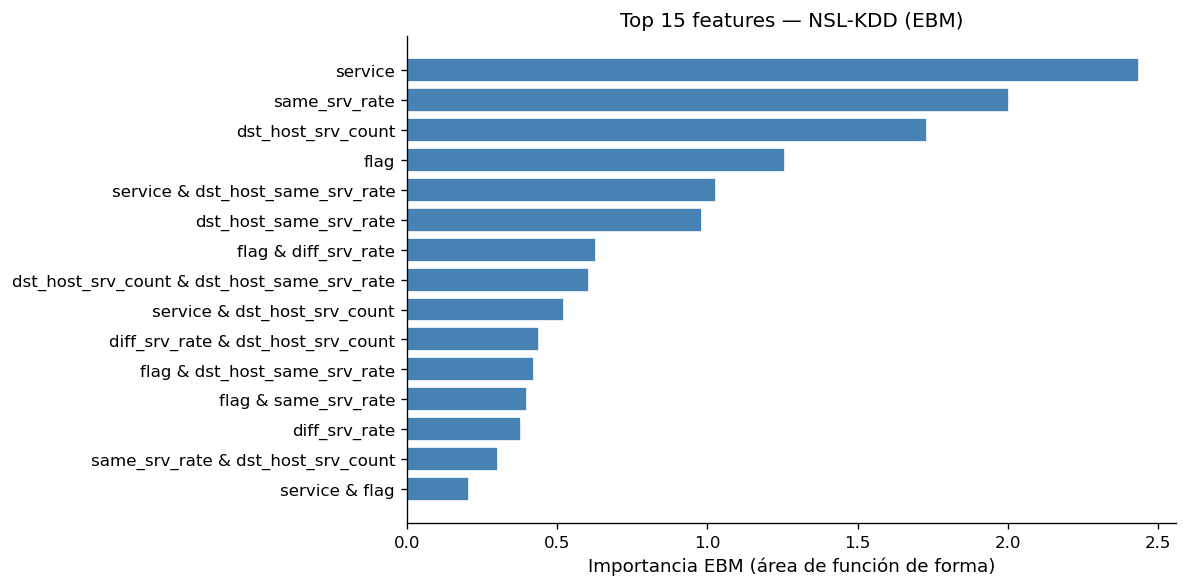

Figura guardada: ebm_nslkdd_multi_importancias.png


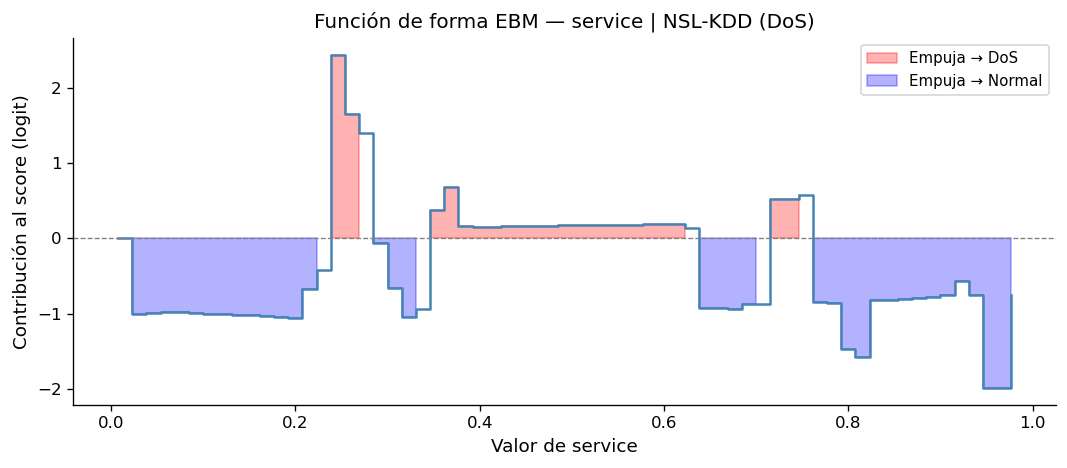

Figura guardada: ebm_nslkdd_multi_shape_service.png

Explicación local — muestra DoS (idx=1)
  Predicción: DoS
  P(Normal) = 0.0000
  P(DoS) = 0.9998
  P(Probe) = 0.0002
  P(R2L) = 0.0000
  P(U2R) = 0.0000

Top 10 contribuciones locales (EBM):
                           feature  contribucion
                              flag      1.621912
                     same_srv_rate      1.366612
                     diff_srv_rate      0.635213
            dst_host_same_srv_rate      0.564699
              flag & diff_srv_rate      0.282496
diff_srv_rate & dst_host_srv_count      0.250021
      service & dst_host_srv_count      0.188347
                           service      0.184506
                dst_host_srv_count      0.175773
     flag & dst_host_same_srv_rate      0.135345


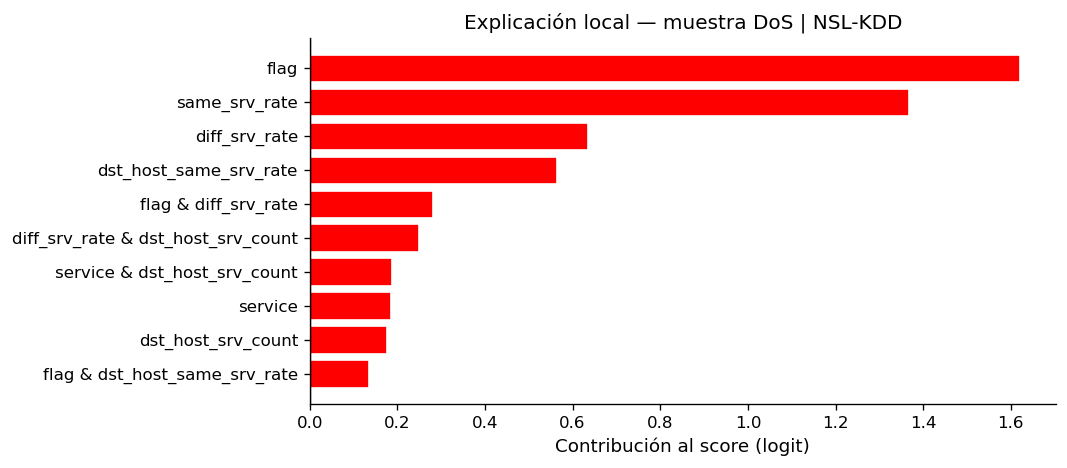

Figura guardada: ebm_nslkdd_multi_explicacion_local.png


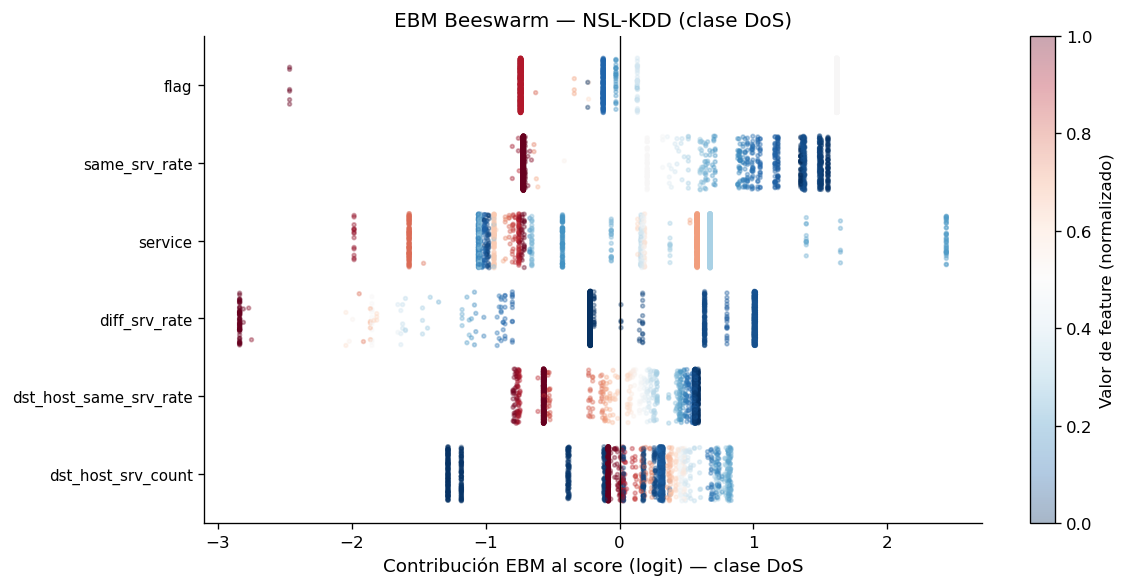

Figura guardada: ebm_nslkdd_beeswarm_dos.png


In [4]:
# explicabilidad intrínseca

# Importancias globales
importancias = ebm_nsl_multi.term_importances()
nombres      = ebm_nsl_multi.term_names_

top_n = 15
idx_sorted = np.argsort(importancias)[::-1][:top_n]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(
    [nombres[i] for i in idx_sorted][::-1],
    [importancias[i] for i in idx_sorted][::-1],
    color='steelblue', edgecolor='white'
)
ax.set_xlabel('Importancia EBM (área de función de forma)', fontsize=11)
ax.set_title(f'Top {top_n} features — NSL-KDD (EBM)', fontsize=12)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('ebm_nslkdd_multi_importancias.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: ebm_nslkdd_multi_importancias.png')

# Función de forma — feature más importante
feat_idx_top    = idx_sorted[0]
feat_nombre     = nombres[feat_idx_top]
term_scores_raw = ebm_nsl_multi.term_scores_[feat_idx_top]
bin_edges       = ebm_nsl_multi.bins_[feat_idx_top][0]

# Multiclase: term_scores_ puede ser 2D (n_bins, n_clases)
if term_scores_raw.ndim == 2:
    CLASE_IDX   = 1  # DoS
    term_scores = term_scores_raw[:, CLASE_IDX]
    clase_label = CLASS_NAMES_NSL_LIST[CLASE_IDX]
else:
    term_scores = term_scores_raw
    clase_label = 'Ataque'

if len(bin_edges) > 1 and len(term_scores) > 1:
    x_vals = bin_edges[:-1]
    y_vals = term_scores[:len(x_vals)]
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.step(x_vals, y_vals, where='post', color='steelblue', linewidth=1.5)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.fill_between(x_vals, y_vals, 0, step='post',
                    where=[v > 0 for v in y_vals],
                    alpha=0.3, color='red', label=f'Empuja → {clase_label}')
    ax.fill_between(x_vals, y_vals, 0, step='post',
                    where=[v < 0 for v in y_vals],
                    alpha=0.3, color='blue', label='Empuja → Normal')
    ax.set_xlabel(f'Valor de {feat_nombre}', fontsize=11)
    ax.set_ylabel('Contribución al score (logit)', fontsize=11)
    ax.set_title(f'Función de forma EBM — {feat_nombre} | NSL-KDD ({clase_label})', fontsize=12)
    ax.legend(fontsize=9)
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(f'ebm_nslkdd_multi_shape_{feat_nombre}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figura guardada: ebm_nslkdd_multi_shape_{feat_nombre}.png')

# Explicación local — muestra DoS
idx_ataque = np.where(y_te_multi == 2)[0][0]
muestra    = X_te_nsl[[idx_ataque]]
pred_local = ebm_nsl_multi.predict(muestra)[0]
prob_local = ebm_nsl_multi.predict_proba(muestra)[0]

print(f'\nExplicación local — muestra DoS (idx={idx_ataque})')
print(f'  Predicción: {CLASS_NAMES_NSL_LIST[pred_local - 1]}')
for cls, p in zip(CLASS_NAMES_NSL_LIST, prob_local):
    print(f'  P({cls}) = {p:.4f}')

scores_locales = ebm_nsl_multi.eval_terms(muestra)[0]
if scores_locales.ndim == 2:
    scores_locales_1d = scores_locales[:, pred_local - 1]
else:
    scores_locales_1d = scores_locales

contrib_df = pd.DataFrame({
    'feature':      nombres,
    'contribucion': scores_locales_1d
}).sort_values('contribucion', key=abs, ascending=False).head(10)

print('\nTop 10 contribuciones locales (EBM):')
print(contrib_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
colores = ['red' if v > 0 else 'steelblue' for v in contrib_df['contribucion']]
ax.barh(contrib_df['feature'][::-1], contrib_df['contribucion'][::-1],
        color=colores[::-1], edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Contribución al score (logit)', fontsize=11)
ax.set_title('Explicación local — muestra DoS | NSL-KDD', fontsize=12)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('ebm_nslkdd_multi_explicacion_local.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: ebm_nslkdd_multi_explicacion_local.png')

# Beeswarm EBM — contribuciones locales (análogo SHAP summary_plot)
np.random.seed(RANDOM_SEED)
idx_bee_nsl = np.random.choice(len(X_te_nsl), min(2000, len(X_te_nsl)), replace=False)
X_bee_nsl   = X_te_nsl[idx_bee_nsl]
sc_bee_raw  = ebm_nsl_multi.eval_terms(X_bee_nsl)
sc_bee_dos  = sc_bee_raw[:, :, 1] if sc_bee_raw.ndim == 3 else sc_bee_raw
n_main_nsl  = len(FEATURE_COLS_NSL)
c_mat_nsl   = sc_bee_dos[:, :n_main_nsl]
mean_abs_nsl = np.abs(c_mat_nsl).mean(axis=0)
order_nsl   = np.argsort(mean_abs_nsl)

fig, ax = plt.subplots(figsize=(10, 5))
for row_i, fi in enumerate(order_nsl):
    vals = c_mat_nsl[:, fi]
    fv   = X_bee_nsl[:, fi]
    fmin, fmax = fv.min(), fv.max()
    norm = (fv - fmin)/(fmax - fmin) if fmax > fmin else np.full(len(fv), 0.5)
    np.random.seed(row_i)
    jitter = np.random.uniform(-0.35, 0.35, size=len(vals))
    sc = ax.scatter(vals, row_i + jitter, c=norm, cmap='RdBu_r',
                    alpha=0.35, s=5, rasterized=True, vmin=0, vmax=1)
ax.set_yticks(range(n_main_nsl))
ax.set_yticklabels([FEATURE_COLS_NSL[i] for i in order_nsl], fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Contribución EBM al score (logit) — clase DoS', fontsize=11)
ax.set_title('EBM Beeswarm — NSL-KDD (clase DoS)', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
plt.colorbar(sc, ax=ax, label='Valor de feature (normalizado)')
plt.tight_layout()
plt.savefig('ebm_nslkdd_beeswarm_dos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: ebm_nslkdd_beeswarm_dos.png')


---
## DATASET 2 — Mirai


In [5]:
# mismo preprocesado que Clasificadores Mirai.ipynb (9 features, label binaria, split 80/20 + MinMaxScaler)

def reclassify_state_mirai(row):
    """Reclasificación semántica idéntica a réplicas Mirai."""
    proto  = row.get('state', row.get('proto', 'OTHER'))
    b_pkts = row.get('b_pkts', 0)
    avg_ps = row.get('avg_pkt_size', 0)
    if proto == 'DNS':             return 'DNS_FLOOD'
    if proto in ('HTTP','HTTPS'):  return 'HTTP_FLOOD'
    if proto == 'SSH':             return 'OTHER'
    if proto == 'UDP_OTHER':
        if b_pkts == 0 and avg_ps < 100: return 'UDP_SMALL_NORESPONSE'
        elif b_pkts == 0:                return 'UDP_LARGE_NORESPONSE'
        else:                            return 'UDP_BIDIRECTIONAL'
    if proto == 'TCP_OTHER':
        if b_pkts == 0 and avg_ps < 80: return 'TCP_SYN_LIKE'
        elif b_pkts == 0:               return 'TCP_ACK_LIKE'
        else:                           return 'TCP_ESTABLISHED'
    return 'OTHER'

HWANG_CLASS_TOTAL = {
    'Normal':      76725, 'ACK_Flood':    7425,
    'DNS_Flood':    4851, 'Mirai_CnC':   76725,
    'GREIP_Flood': 27801, 'HTTP_Flood':    135,
    'SYN_Flood':   76725, 'UDP_Flood':   31878,
    'VSE_Flood':    4986,
}

FEATURE_COLS_MIRAI = [
    'n_pkts','n_bytes','f_pkts','f_bytes',
    'b_pkts','b_bytes','duration','state'
]

def find_mirai_file():
    # Ruta canónica del proyecto
    canonical = (Path.cwd().parent / "data" / "flows.csv")
    if canonical.exists():
        return canonical
    # Búsqueda por nombre en rutas habituales
    for base in [Path('.'), Path.home()/'Downloads', Path.home()/'.cache',
                 Path.home()/'markov_mirai']:
        for f in base.rglob('*.csv'):
            if any(k in f.name.lower() for k in ('mirai', 'hwang', 'flows')):
                return f
    raise FileNotFoundError(
        "No se encontró el dataset Mirai.\n"
        "Ruta esperada: C:\\Users\\user\\markov_mirai\\flows.csv"
    )

try:
    ruta_mirai = find_mirai_file()
    print(f'Cargando Mirai desde: {ruta_mirai}')
    df_mirai = pd.read_csv(ruta_mirai)

    if 'state' in df_mirai.columns:
        df_mirai['state'] = df_mirai.apply(reclassify_state_mirai, axis=1)

    np.random.seed(RANDOM_SEED)
    idx_keep = []
    for cls_name, n_total in HWANG_CLASS_TOTAL.items():
        if 'class_name' not in df_mirai.columns: continue
        idx_cls = np.where(df_mirai['class_name'].values == cls_name)[0]
        if len(idx_cls) == 0: continue
        if len(idx_cls) > n_total:
            idx_cls = np.random.choice(idx_cls, n_total, replace=False)
        idx_keep.append(idx_cls)
    if idx_keep:
        df_mirai = df_mirai.iloc[np.sort(np.concatenate(idx_keep))].reset_index(drop=True)

    le_state = LabelEncoder()
    df_mirai['state'] = le_state.fit_transform(df_mirai['state'].astype(str))

    CLASS_NAMES_MIRAI = list(HWANG_CLASS_TOTAL.keys())
    class_to_int  = {c: i for i, c in enumerate(CLASS_NAMES_MIRAI)}
    y_mirai_multi = df_mirai['class_name'].map(class_to_int).values

    # Etiqueta binaria directamente desde columna 'label' del CSV (igual que Clasificadores Mirai.ipynb)
    y_mirai_bin = df_mirai['label'].values.astype(int)

    feats_mirai = [f for f in FEATURE_COLS_MIRAI if f in df_mirai.columns]
    X_mirai = df_mirai[feats_mirai].apply(pd.to_numeric, errors='coerce').fillna(0).values.astype(np.float32)

    Xm_tr, Xm_te, ym_tr_bin, ym_te_bin = train_test_split(
        X_mirai, y_mirai_bin,
        test_size=0.20, random_state=RANDOM_SEED, stratify=y_mirai_bin
    )

    # MinMaxScaler post-split (igual que Clasificadores Mirai.ipynb)
    scaler_mirai = MinMaxScaler()
    Xm_tr = scaler_mirai.fit_transform(Xm_tr)
    Xm_te = scaler_mirai.transform(Xm_te)

    print(f'Mirai cargado: {len(df_mirai):,} instancias')
    print(f'Train: {len(Xm_tr):,} | Test: {len(Xm_te):,}')
    print(f'Features: {len(feats_mirai)}')
    MIRAI_DISPONIBLE = True

except FileNotFoundError as e:
    print(f'AVISO: {e}')
    MIRAI_DISPONIBLE = False


Cargando Mirai desde: C:\Users\user\markov_mirai\flows.csv


Mirai cargado: 161,384 instancias
Train: 129,107 | Test: 32,277
Features: 8


Entrenando EBM (no cacheado): ebm_mirai_xai_sinleak.joblib ...


EBM guardado en: C:\Users\user\TFM\modelos\ebm_mirai_xai_sinleak.joblib
                    EBM — Mirai (Binario)                   
  Accuracy   : 0.9982
  Precision  : 0.9888  (macro)
  Recall     : 0.9921  (macro)
  F1-Score   : 0.9904  (macro)
  AUC-ROC    : 0.9999
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1559
           1       1.00      1.00      1.00     30718

    accuracy                           1.00     32277
   macro avg       0.99      0.99      0.99     32277
weighted avg       1.00      1.00      1.00     32277



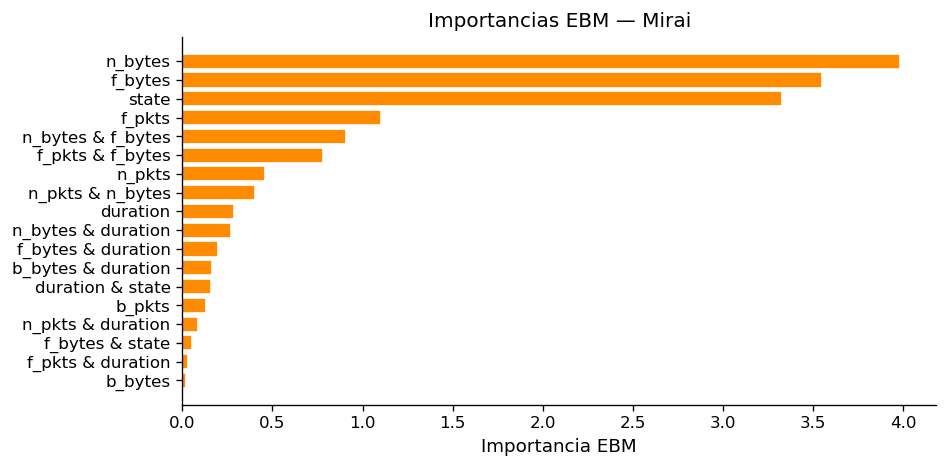

In [6]:
# entrenamiento y evaluación EBM

if MIRAI_DISPONIBLE:
    ebm_mirai = ExplainableBoostingClassifier(
        max_bins         = 256,
        interactions     = 10,
        learning_rate    = 0.01,
        max_rounds       = 5000,
        min_samples_leaf = 2,
        n_jobs           = 1,
        random_state     = RANDOM_SEED,
        feature_names    = feats_mirai,
    )
    ebm_mirai = get_or_train_ebm(ebm_mirai, Xm_tr, ym_tr_bin, 'ebm_mirai_xai_sinleak.joblib')
    resultados_mirai = evaluar_modelo(
        ebm_mirai, Xm_te, ym_te_bin,
        nombre_dataset='Mirai (Binario)'
    )

    # Importancias globales Mirai
    imp_mirai = ebm_mirai.term_importances()
    nom_mirai = ebm_mirai.term_names_
    idx_m = np.argsort(imp_mirai)[::-1]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh([nom_mirai[i] for i in idx_m][::-1],
            [imp_mirai[i] for i in idx_m][::-1],
            color='darkorange', edgecolor='white')
    ax.set_title('Importancias EBM — Mirai', fontsize=12)
    ax.set_xlabel('Importancia EBM', fontsize=11)
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('ebm_mirai_importancias.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Mirai no disponible — bloque saltado.')


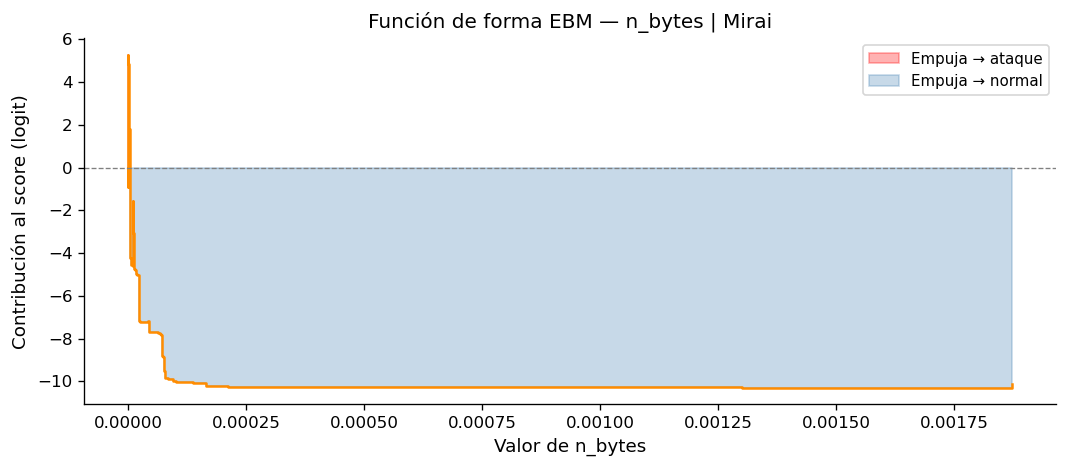

Figura guardada: ebm_mirai_shape_n_bytes.png

Explicación local Mirai — muestra 0
  Predicción: ATAQUE
  P(normal) = 0.0000 | P(ataque) = 1.0000

Top 10 contribuciones locales (EBM Mirai):
           feature  contribucion
           n_bytes      4.844527
           f_bytes     -3.109533
             state      2.348801
            f_pkts     -0.662408
  n_pkts & n_bytes     -0.384990
  f_pkts & f_bytes     -0.360329
            n_pkts     -0.346279
 n_bytes & f_bytes     -0.315589
n_bytes & duration     -0.237560
          duration     -0.157733


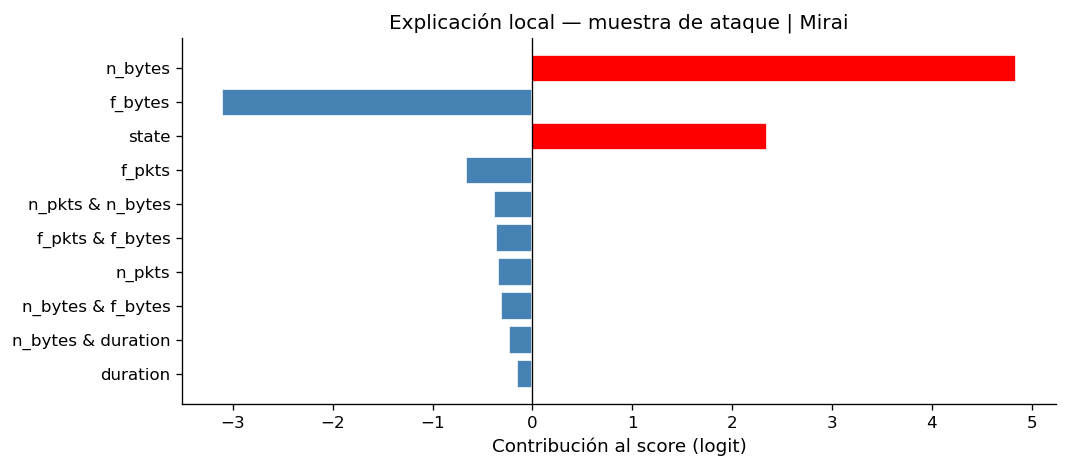

Figura guardada: ebm_mirai_explicacion_local.png


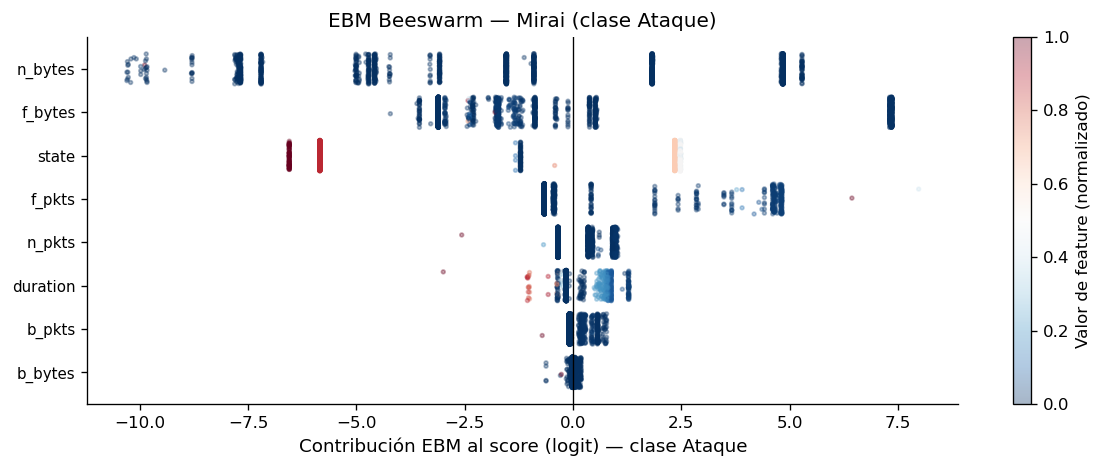

Figura guardada: ebm_mirai_beeswarm.png


In [7]:
# explicabilidad intrínseca (binario)

if MIRAI_DISPONIBLE:
    imp_m    = ebm_mirai.term_importances()
    nom_m    = ebm_mirai.term_names_
    top_idx  = np.argsort(imp_m)[::-1][0]
    feat_top = nom_m[top_idx]

    # Función de forma — feature más importante
    scores_m    = ebm_mirai.term_scores_[top_idx]
    bin_edges_m = ebm_mirai.bins_[top_idx][0]

    if scores_m.ndim == 1 and len(bin_edges_m) > 1 and len(scores_m) > 1:
        x_m = bin_edges_m[:-1]
        y_m = scores_m[:len(x_m)]
        fig, ax = plt.subplots(figsize=(9, 4))
        ax.step(x_m, y_m, where='post', color='darkorange', linewidth=1.5)
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
        ax.fill_between(x_m, y_m, 0, step='post',
                        where=[v > 0 for v in y_m],
                        alpha=0.3, color='red', label='Empuja → ataque')
        ax.fill_between(x_m, y_m, 0, step='post',
                        where=[v < 0 for v in y_m],
                        alpha=0.3, color='steelblue', label='Empuja → normal')
        ax.set_xlabel(f'Valor de {feat_top}', fontsize=11)
        ax.set_ylabel('Contribución al score (logit)', fontsize=11)
        ax.set_title(f'Función de forma EBM — {feat_top} | Mirai', fontsize=12)
        ax.legend(fontsize=9)
        ax.spines[['top','right']].set_visible(False)
        plt.tight_layout()
        plt.savefig(f'ebm_mirai_shape_{feat_top}.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Figura guardada: ebm_mirai_shape_{feat_top}.png')

    # Explicación local — muestra de ataque
    idx_at_m  = np.where(ym_te_bin == 1)[0][0]
    mues_m    = Xm_te[[idx_at_m]]
    pred_m    = ebm_mirai.predict(mues_m)[0]
    prob_m    = ebm_mirai.predict_proba(mues_m)[0]
    pred_lbl  = 'ATAQUE' if pred_m == 1 else 'NORMAL'

    print(f'\nExplicación local Mirai — muestra {idx_at_m}')
    print(f'  Predicción: {pred_lbl}')
    print(f'  P(normal) = {prob_m[0]:.4f} | P(ataque) = {prob_m[1]:.4f}')

    sc_m = ebm_mirai.eval_terms(mues_m)[0]
    contrib_m = pd.DataFrame({
        'feature': nom_m, 'contribucion': sc_m
    }).sort_values('contribucion', key=abs, ascending=False).head(10)

    print('\nTop 10 contribuciones locales (EBM Mirai):')
    print(contrib_m.to_string(index=False))

    fig, ax = plt.subplots(figsize=(9, 4))
    col_m = ['red' if v > 0 else 'steelblue' for v in contrib_m['contribucion']]
    ax.barh(contrib_m['feature'][::-1], contrib_m['contribucion'][::-1],
            color=col_m[::-1], edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Contribución al score (logit)', fontsize=11)
    ax.set_title('Explicación local — muestra de ataque | Mirai', fontsize=12)
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('ebm_mirai_explicacion_local.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figura guardada: ebm_mirai_explicacion_local.png')

    # Beeswarm EBM — contribuciones locales (análogo SHAP summary_plot)
    np.random.seed(RANDOM_SEED)
    idx_bee_m  = np.random.choice(len(Xm_te), min(2000, len(Xm_te)), replace=False)
    X_bee_m    = Xm_te[idx_bee_m]
    sc_bee_m   = ebm_mirai.eval_terms(X_bee_m)
    sc_bee_at  = sc_bee_m[:, :, 1] if sc_bee_m.ndim == 3 else sc_bee_m
    n_main_m   = len(feats_mirai)
    c_mat_m    = sc_bee_at[:, :n_main_m]
    mean_abs_m = np.abs(c_mat_m).mean(axis=0)
    order_m    = np.argsort(mean_abs_m)

    fig, ax = plt.subplots(figsize=(10, 4))
    for row_i, fi in enumerate(order_m):
        vals = c_mat_m[:, fi]
        fv   = X_bee_m[:, fi]
        fmin, fmax = fv.min(), fv.max()
        norm = (fv - fmin)/(fmax - fmin) if fmax > fmin else np.full(len(fv), 0.5)
        np.random.seed(row_i)
        jitter = np.random.uniform(-0.35, 0.35, size=len(vals))
        sc = ax.scatter(vals, row_i + jitter, c=norm, cmap='RdBu_r',
                        alpha=0.35, s=5, rasterized=True, vmin=0, vmax=1)
    ax.set_yticks(range(n_main_m))
    ax.set_yticklabels([feats_mirai[i] for i in order_m], fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Contribución EBM al score (logit) — clase Ataque', fontsize=11)
    ax.set_title('EBM Beeswarm — Mirai (clase Ataque)', fontsize=12)
    ax.spines[['top', 'right']].set_visible(False)
    plt.colorbar(sc, ax=ax, label='Valor de feature (normalizado)')
    plt.tight_layout()
    plt.savefig('ebm_mirai_beeswarm.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figura guardada: ebm_mirai_beeswarm.png')
else:
    print('Mirai no disponible — bloque saltado.')


---
## DATASET 3 — DS2OS


In [8]:
# carga y preprocesamiento
# Preprocesamiento IDÉNTICO a CLASIFICADORES DS2OS.ipynb (6 pasos)

CLASS_MAP = {
    'normal'                        : 'Normal',
    'anomalous(DoSattack)'          : 'DoS',
    'anomalous(scan)'               : 'Scan',
    'anomalous(malitiousControl)'   : 'MaliciousControl',
    'anomalous(malitiousOperation)' : 'MaliciousOperation',
    'anomalous(spying)'             : 'Spying',
    'anomalous(dataProbing)'        : 'DataProbing',
    'anomalous(wrongSetUp)'         : 'WrongSetUp',
}
CLASS_TO_INT = {v: i for i, v in enumerate(CLASS_MAP.values())}
INT_TO_CLASS = {v: k for k, v in CLASS_TO_INT.items()}

CAT_COLS_DS2OS = [
    'sourceID', 'sourceAddress', 'sourceType', 'sourceLocation',
    'destinationServiceAddress', 'destinationServiceType',
    'destinationLocation', 'accessedNodeAddress', 'accessedNodeType', 'operation',
]
FEAT_DS2OS = CAT_COLS_DS2OS + ['value']  # 11 features

SEARCH_PATHS_DS2OS = [
    Path("DS2OS.csv"),
    Path.home() / "Downloads" / "DS2OS.csv",
    (Path.home() / ".cache" / "kagglehub" / "datasets" / "libamariyam" / "ds2os-dataset" / "versions" / "1" / "DS2OS.csv"),
]

try:
    ruta_ds2os = next((p for p in SEARCH_PATHS_DS2OS if p.exists()), None)
    if ruta_ds2os is None:
        raise FileNotFoundError("No se encontró DS2OS.csv")

    print(f'Cargando DS2OS desde: {ruta_ds2os}')
    df_ds2os = pd.read_csv(ruta_ds2os)

    # Paso 1 — NaN en accessedNodeType
    df_ds2os['accessedNodeType'] = df_ds2os['accessedNodeType'].fillna('Malicious')

    # Paso 2 — Limpiar columna value
    df_ds2os['value'] = df_ds2os['value'].replace({'False': 0, 'True': 1, 'Twenty': 20, 'none': 0})
    df_ds2os['value'] = pd.to_numeric(df_ds2os['value'], errors='coerce').fillna(0)

    # Paso 3 — Eliminar timestamp
    df_ds2os = df_ds2os.drop(columns=['timestamp'])

    # Paso 4 — Codificar etiquetas (igual que réplica)
    df_ds2os['y'] = df_ds2os['normality'].map(CLASS_MAP).map(CLASS_TO_INT).astype(np.int8)
    y_ds2os_bin   = (df_ds2os['normality'] != 'normal').astype(int).values
    df_ds2os = df_ds2os.drop(columns=['normality'])

    # Paso 5 — Label Encoding categóricas
    for col in CAT_COLS_DS2OS:
        df_ds2os[col] = LabelEncoder().fit_transform(df_ds2os[col].astype(str))

    X_ds2os      = df_ds2os[FEAT_DS2OS].values.astype(np.float32)
    y_ds2os_multi = df_ds2os['y'].values

    # Paso 6 — Split 80/20 + StandardScaler post-split
    Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(
        X_ds2os, y_ds2os_multi,
        test_size=0.20, random_state=RANDOM_SEED, stratify=y_ds2os_multi
    )
    scaler_ds2os = StandardScaler()
    Xd_tr = scaler_ds2os.fit_transform(Xd_tr)
    Xd_te = scaler_ds2os.transform(Xd_te)

    print(f'DS2OS cargado: {len(df_ds2os):,} instancias')
    print(f'Train: {len(Xd_tr):,} | Test: {len(Xd_te):,}')
    print(f'Tasa de anomalías: {y_ds2os_bin.mean()*100:.1f}%')
    print(f'\n{"Clase":<22} {"Total":>8} {"Train":>8}  {"Test":>6}')
    for cls_id, cls_name in INT_TO_CLASS.items():
        print(f'  {cls_name:<20} {(y_ds2os_multi==cls_id).sum():>8,} '
              f'{(yd_tr==cls_id).sum():>8,}  {(yd_te==cls_id).sum():>6,}')
    DS2OS_DISPONIBLE = True

except FileNotFoundError as e:
    print(f'AVISO: {e}')
    DS2OS_DISPONIBLE = False


Cargando DS2OS desde: C:\Users\user\.cache\kagglehub\datasets\libamariyam\ds2os-dataset\versions\1\DS2OS.csv


DS2OS cargado: 357,952 instancias
Train: 286,361 | Test: 71,591
Tasa de anomalías: 2.8%

Clase                     Total    Train    Test
  Normal                347,935  278,347  69,588
  DoS                     5,780    4,624   1,156
  Scan                    1,547    1,237     310
  MaliciousControl          889      711     178
  MaliciousOperation        805      644     161
  Spying                    532      426     106
  DataProbing               342      274      68
  WrongSetUp                122       98      24


In [9]:
# entrenamiento y evaluación EBM

if DS2OS_DISPONIBLE:
    ebm_ds2os = ExplainableBoostingClassifier(
        max_bins         = 256,
        interactions     = 10,
        learning_rate    = 0.01,
        max_rounds       = 5000,
        min_samples_leaf = 2,
        n_jobs           = 1,
        random_state     = RANDOM_SEED,
        feature_names    = FEAT_DS2OS,
    )
    ebm_ds2os = get_or_train_ebm(ebm_ds2os, Xd_tr, yd_tr, 'ebm_ds2os_xai.joblib')
    resultados_ds2os = evaluar_modelo(
        ebm_ds2os, Xd_te, yd_te,
        nombre_dataset='DS2OS'
    )
else:
    print('DS2OS no disponible — bloque saltado.')


Recargando EBM cacheado: ebm_ds2os_xai.joblib


                         EBM — DS2OS                        
  Accuracy   : 0.9940
  Precision  : 0.9853  (macro)
  Recall     : 0.9464  (macro)
  F1-Score   : 0.9619  (macro)
  AUC-ROC    : 0.9996
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     69588
           1       0.98      0.68      0.80      1156
           2       0.99      0.89      0.94       310
           3       1.00      1.00      1.00       178
           4       0.95      1.00      0.97       161
           5       0.96      1.00      0.98       106
           6       1.00      1.00      1.00        68
           7       1.00      1.00      1.00        24

    accuracy                           0.99     71591
   macro avg       0.99      0.95      0.96     71591
weighted avg       0.99      0.99      0.99     71591



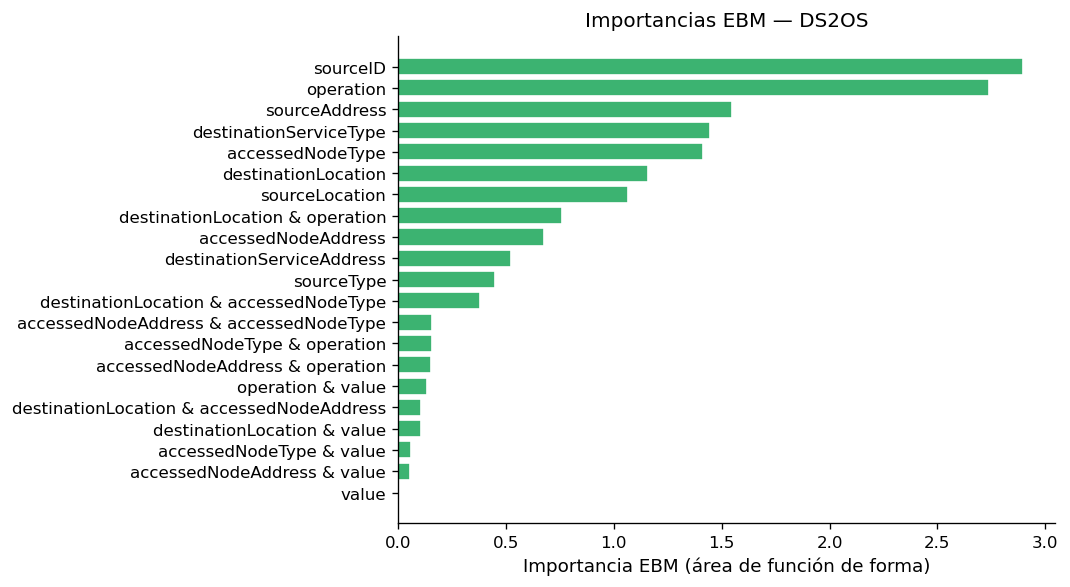

Figura guardada: ebm_ds2os_importancias.png


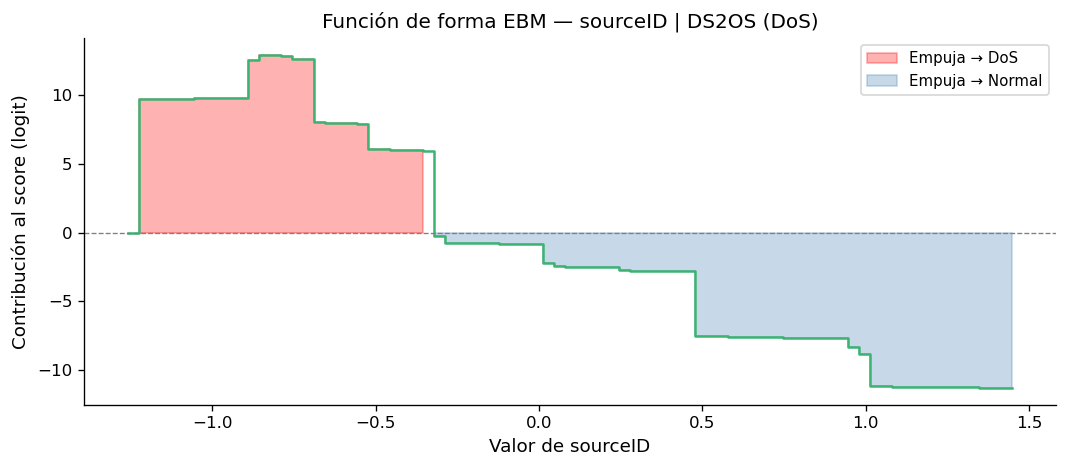

Figura guardada: ebm_ds2os_shape_sourceID.png

Explicación local DS2OS — muestra 0
  Clase real: Scan
  Predicción: Normal
  P(Normal                ) = 0.8886
  P(DoS                   ) = 0.0000
  P(Scan                  ) = 0.1086
  P(MaliciousControl      ) = 0.0000
  P(MaliciousOperation    ) = 0.0000
  P(Spying                ) = 0.0028
  P(DataProbing           ) = 0.0000
  P(WrongSetUp            ) = 0.0000

Top 10 contribuciones locales (EBM DS2OS):
                                  feature  contribucion
                                 sourceID     -1.566163
                   destinationServiceType      0.672518
                            sourceAddress     -0.495738
                         accessedNodeType     -0.475837
                           sourceLocation     -0.449216
                      destinationLocation     -0.209415
                               sourceType      0.074204
                                operation     -0.070556
   accessedNodeAddress & accessed

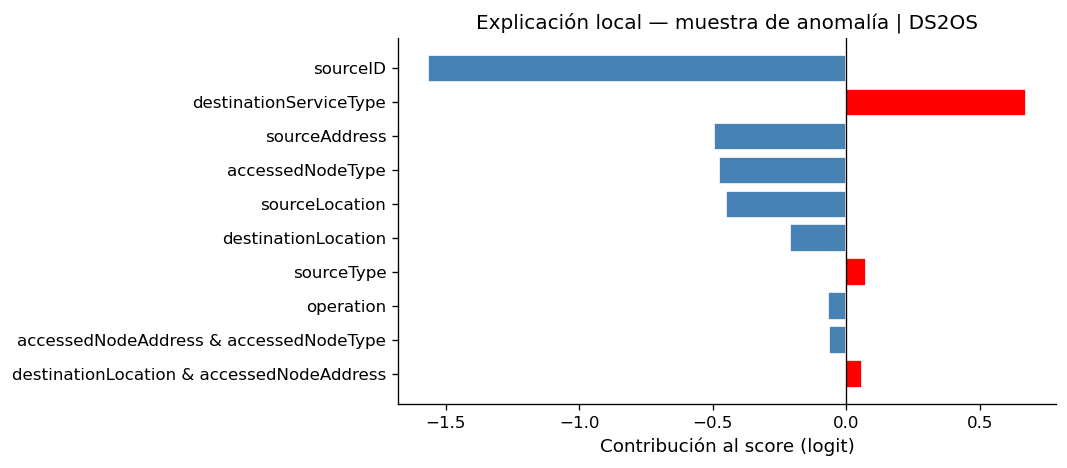

Figura guardada: ebm_ds2os_explicacion_local.png


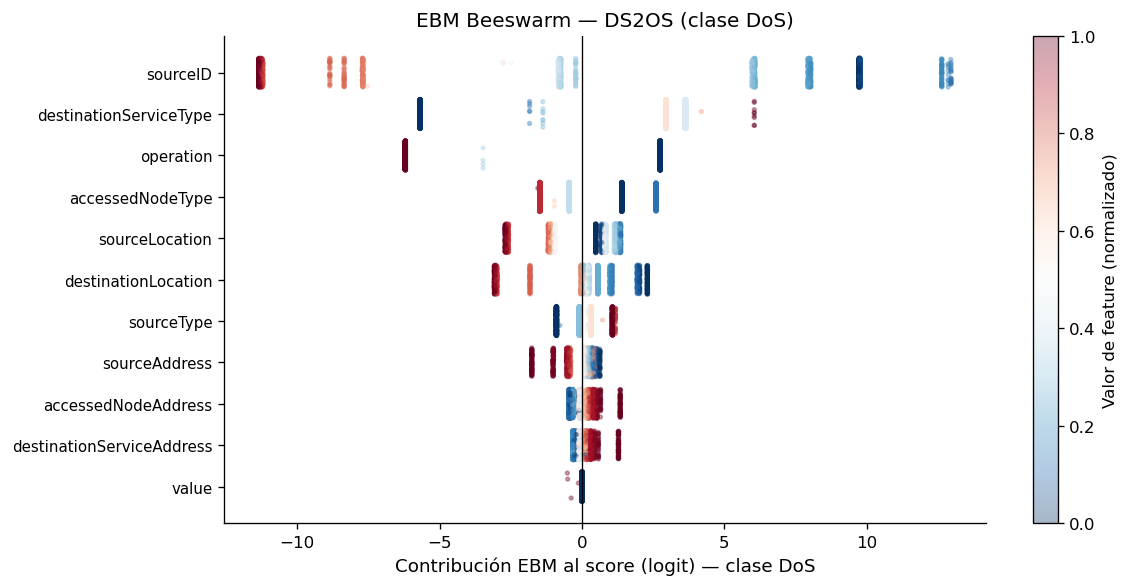

Figura guardada: ebm_ds2os_beeswarm_dos.png


In [10]:
# explicabilidad intrínseca

if DS2OS_DISPONIBLE:
    imp_d = ebm_ds2os.term_importances()
    nom_d = ebm_ds2os.term_names_
    idx_d = np.argsort(imp_d)[::-1]

    # Importancias globales
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh([nom_d[i] for i in idx_d][::-1],
            [imp_d[i] for i in idx_d][::-1],
            color='mediumseagreen', edgecolor='white')
    ax.set_title('Importancias EBM — DS2OS', fontsize=12)
    ax.set_xlabel('Importancia EBM (área de función de forma)', fontsize=11)
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('ebm_ds2os_importancias.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figura guardada: ebm_ds2os_importancias.png')

    # Función de forma — feature más importante (clase DoS)
    feat_d_idx   = idx_d[0]
    feat_d_nom   = nom_d[feat_d_idx]
    scores_d_raw = ebm_ds2os.term_scores_[feat_d_idx]
    bins_d       = ebm_ds2os.bins_[feat_d_idx][0]

    if scores_d_raw.ndim == 2:
        scores_d      = scores_d_raw[:, 1]
        clase_d_label = 'DoS'
    else:
        scores_d      = scores_d_raw
        clase_d_label = 'Anomalía'

    if len(bins_d) > 1 and len(scores_d) > 1:
        x_d = bins_d[:-1]
        y_d = scores_d[:len(x_d)]
        fig, ax = plt.subplots(figsize=(9, 4))
        ax.step(x_d, y_d, where='post', color='mediumseagreen', linewidth=1.5)
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
        ax.fill_between(x_d, y_d, 0, step='post',
                        where=[v > 0 for v in y_d],
                        alpha=0.3, color='red', label=f'Empuja → {clase_d_label}')
        ax.fill_between(x_d, y_d, 0, step='post',
                        where=[v < 0 for v in y_d],
                        alpha=0.3, color='steelblue', label='Empuja → Normal')
        ax.set_xlabel(f'Valor de {feat_d_nom}', fontsize=11)
        ax.set_ylabel('Contribución al score (logit)', fontsize=11)
        ax.set_title(f'Función de forma EBM — {feat_d_nom} | DS2OS ({clase_d_label})', fontsize=12)
        ax.legend(fontsize=9)
        ax.spines[['top','right']].set_visible(False)
        plt.tight_layout()
        plt.savefig(f'ebm_ds2os_shape_{feat_d_nom}.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Figura guardada: ebm_ds2os_shape_{feat_d_nom}.png')

    # Explicación local — muestra de anomalía
    idx_anom_d = np.where(yd_te != 0)[0][0]
    mues_d     = Xd_te[[idx_anom_d]]
    pred_d     = ebm_ds2os.predict(mues_d)[0]
    prob_d     = ebm_ds2os.predict_proba(mues_d)[0]

    print(f'\nExplicación local DS2OS — muestra {idx_anom_d}')
    print(f'  Clase real: {INT_TO_CLASS[yd_te[idx_anom_d]]}')
    print(f'  Predicción: {INT_TO_CLASS[pred_d]}')
    for cls_id, p in enumerate(prob_d):
        print(f'  P({INT_TO_CLASS[cls_id]:<22}) = {p:.4f}')

    sc_d = ebm_ds2os.eval_terms(mues_d)[0]
    sc_d_1d = sc_d[:, pred_d] if sc_d.ndim == 2 else sc_d

    contrib_d = pd.DataFrame({
        'feature': nom_d, 'contribucion': sc_d_1d
    }).sort_values('contribucion', key=abs, ascending=False).head(10)

    print('\nTop 10 contribuciones locales (EBM DS2OS):')
    print(contrib_d.to_string(index=False))

    fig, ax = plt.subplots(figsize=(9, 4))
    col_d = ['red' if v > 0 else 'steelblue' for v in contrib_d['contribucion']]
    ax.barh(contrib_d['feature'][::-1], contrib_d['contribucion'][::-1],
            color=col_d[::-1], edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Contribución al score (logit)', fontsize=11)
    ax.set_title('Explicación local — muestra de anomalía | DS2OS', fontsize=12)
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('ebm_ds2os_explicacion_local.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figura guardada: ebm_ds2os_explicacion_local.png')

    # Beeswarm EBM — contribuciones locales (análogo SHAP summary_plot)
    np.random.seed(RANDOM_SEED)
    idx_bee_d  = np.random.choice(len(Xd_te), min(2000, len(Xd_te)), replace=False)
    X_bee_d    = Xd_te[idx_bee_d]
    sc_bee_d   = ebm_ds2os.eval_terms(X_bee_d)
    sc_bee_dos_d = sc_bee_d[:, :, 1] if sc_bee_d.ndim == 3 else sc_bee_d
    n_main_d   = len(FEAT_DS2OS)
    c_mat_d    = sc_bee_dos_d[:, :n_main_d]
    mean_abs_d = np.abs(c_mat_d).mean(axis=0)
    order_d    = np.argsort(mean_abs_d)

    fig, ax = plt.subplots(figsize=(10, 5))
    for row_i, fi in enumerate(order_d):
        vals = c_mat_d[:, fi]
        fv   = X_bee_d[:, fi]
        fmin, fmax = fv.min(), fv.max()
        norm = (fv - fmin)/(fmax - fmin) if fmax > fmin else np.full(len(fv), 0.5)
        np.random.seed(row_i)
        jitter = np.random.uniform(-0.35, 0.35, size=len(vals))
        sc = ax.scatter(vals, row_i + jitter, c=norm, cmap='RdBu_r',
                        alpha=0.35, s=5, rasterized=True, vmin=0, vmax=1)
    ax.set_yticks(range(n_main_d))
    ax.set_yticklabels([FEAT_DS2OS[i] for i in order_d], fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Contribución EBM al score (logit) — clase DoS', fontsize=11)
    ax.set_title('EBM Beeswarm — DS2OS (clase DoS)', fontsize=12)
    ax.spines[['top', 'right']].set_visible(False)
    plt.colorbar(sc, ax=ax, label='Valor de feature (normalizado)')
    plt.tight_layout()
    plt.savefig('ebm_ds2os_beeswarm_dos.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figura guardada: ebm_ds2os_beeswarm_dos.png')
else:
    print('DS2OS no disponible — bloque saltado.')


---
## RESUMEN COMPARATIVO — EBM vs Modelos Replicados

## Permutation Importance (PI)

              Permutation Importance - EBM - NSL-KDD              


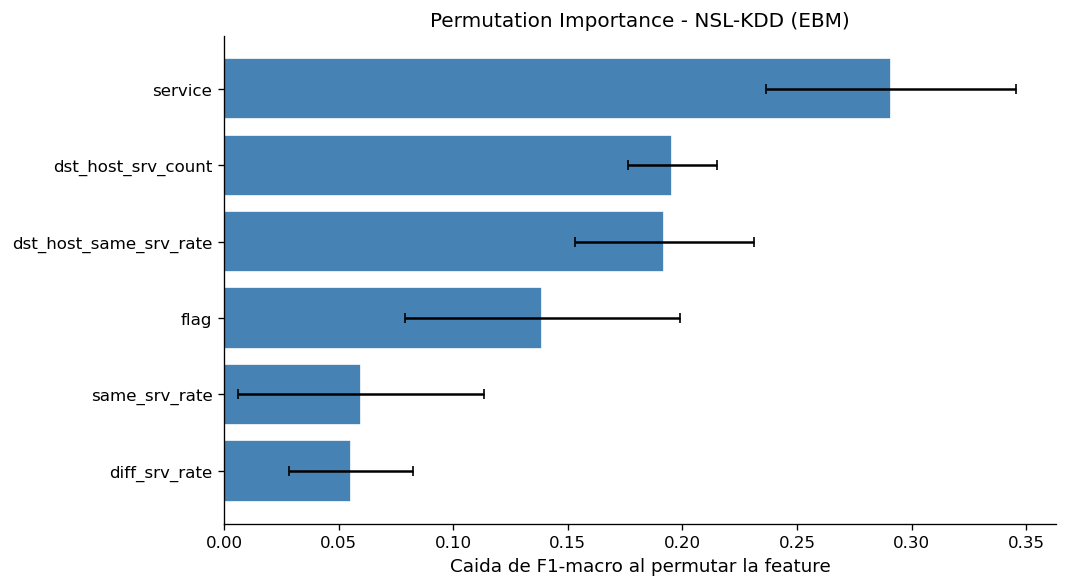

Figura guardada: pi_ebm_nslkdd.png

Feature                     PI media   +/-std  rank PI  rank shape
------------------------------------------------------------------
service                       0.2910   0.0547        1           1
dst_host_srv_count            0.1956   0.0194        2           3
dst_host_same_srv_rate        0.1921   0.0390        3           5
flag                          0.1389   0.0599        4           4
same_srv_rate                 0.0597   0.0536        5           2
diff_srv_rate                 0.0553   0.0271        6           6
               Permutation Importance - EBM - Mirai               


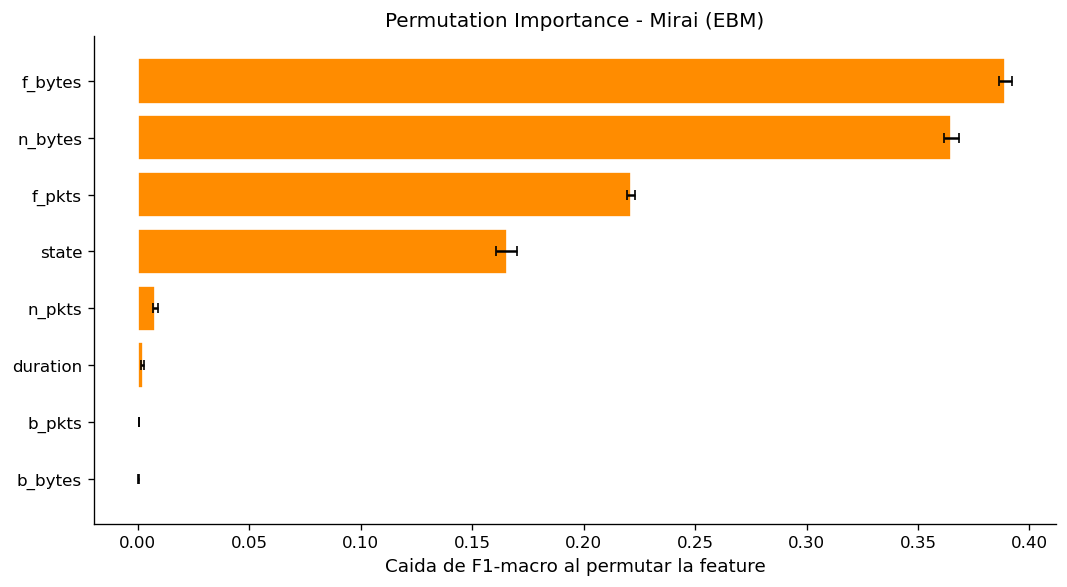

Figura guardada: pi_ebm_mirai.png

Feature                     PI media   +/-std  rank PI  rank shape
------------------------------------------------------------------
f_bytes                       0.3892   0.0031        1           2
n_bytes                       0.3648   0.0033        2           1
f_pkts                        0.2212   0.0016        3           4
state                         0.1654   0.0047        4           3
n_pkts                        0.0078   0.0012        5           5
duration                      0.0023   0.0007        6           6
b_pkts                        0.0006   0.0002        7           7
b_bytes                       0.0002   0.0003        8           8
               Permutation Importance - EBM - DS2OS               


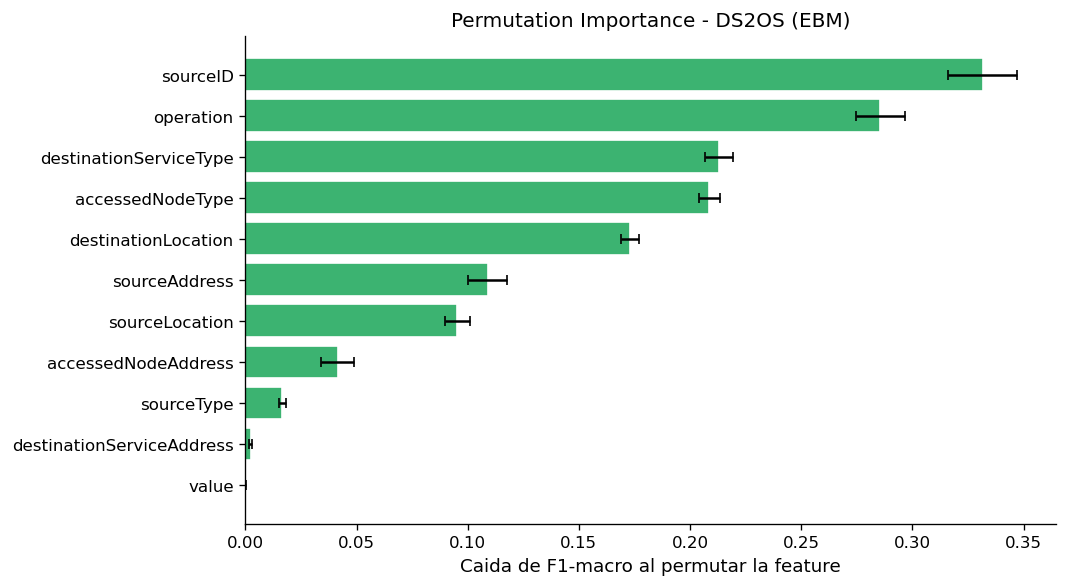

Figura guardada: pi_ebm_ds2os.png

Feature                     PI media   +/-std  rank PI  rank shape
------------------------------------------------------------------
sourceID                      0.3316   0.0156        1           1
operation                     0.2854   0.0110        2           2
destinationServiceType        0.2130   0.0064        3           4
accessedNodeType              0.2086   0.0046        4           5
destinationLocation           0.1731   0.0041        5           6
sourceAddress                 0.1089   0.0086        6           3
sourceLocation                0.0954   0.0056        7           7
accessedNodeAddress           0.0416   0.0075        8           8
sourceType                    0.0166   0.0015        9          10
destinationServiceAddress     0.0023   0.0009       10           9
value                         0.0002   0.0002       11          11


In [11]:
# permutation Importance (EBM, 3 datasets)

from sklearn.inspection import permutation_importance

def pi_ebm(modelo, X_te, y_te, feat_names, nombre_ds, color, fname):
    print('=' * 66)
    print(f' Permutation Importance - EBM - {nombre_ds} '.center(66))
    print('=' * 66)

    pi = permutation_importance(
        modelo, X_te, y_te,
        n_repeats=10, scoring='f1_macro', random_state=RANDOM_SEED,
    )
    orden = np.argsort(pi.importances_mean)[::-1]

    # Bar chart con barras de error (std de los 10 repeats)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(
        [feat_names[i] for i in orden][::-1],
        [pi.importances_mean[i] for i in orden][::-1],
        xerr=[pi.importances_std[i] for i in orden][::-1],
        color=color, edgecolor='white', capsize=3,
    )
    ax.set_xlabel('Caida de F1-macro al permutar la feature', fontsize=11)
    ax.set_title(f'Permutation Importance - {nombre_ds} (EBM)', fontsize=12)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figura guardada: {fname}')

    # Tabla de consistencia: ranking PI vs ranking shape functions
    imp_dict  = dict(zip(modelo.term_names_, modelo.term_importances()))
    nativo    = np.array([imp_dict.get(f, np.nan) for f in feat_names])
    orden_nat = np.argsort(nativo)[::-1]
    rank_pi   = {feat_names[i]: r for r, i in enumerate(orden, 1)}
    rank_nat  = {feat_names[i]: r for r, i in enumerate(orden_nat, 1)}

    print(f'\n{"Feature":<26}{"PI media":>10}{"+/-std":>9}{"rank PI":>9}{"rank shape":>12}')
    print('-' * 66)
    for i in orden:
        f = feat_names[i]
        print(f'{f:<26}{pi.importances_mean[i]:>10.4f}{pi.importances_std[i]:>9.4f}'
              f'{rank_pi[f]:>9}{rank_nat[f]:>12}')
    return pi

# NSL-KDD
pi_ebm_nsl = pi_ebm(ebm_nsl_multi, X_te_nsl, y_te_multi, FEATURE_COLS_NSL,
                    'NSL-KDD', 'steelblue', 'pi_ebm_nslkdd.png')

# Mirai
if MIRAI_DISPONIBLE:
    pi_ebm_mirai = pi_ebm(ebm_mirai, Xm_te, ym_te_bin, feats_mirai,
                          'Mirai', 'darkorange', 'pi_ebm_mirai.png')

# DS2OS
if DS2OS_DISPONIBLE:
    pi_ebm_ds2os = pi_ebm(ebm_ds2os, Xd_te, yd_te, FEAT_DS2OS,
                          'DS2OS', 'mediumseagreen', 'pi_ebm_ds2os.png')


### Export de rankings (shape + PI-EBM) a JSON

In [12]:
# EXPORT - rankings XAI del EBM (shape + PI-EBM) a JSON
import json
from pathlib import Path
RESULTS_DIR = Path('C:/Users/user/TFM')

export_ebm = {}
def _add_ebm(nombre, modelo, feat_names, pi):
    imp = dict(zip(modelo.term_names_, modelo.term_importances()))
    export_ebm[nombre] = {
        f: {'shape': float(imp.get(f, float('nan'))),
            'pi_ebm_mean': float(pi.importances_mean[i]),
            'pi_ebm_std':  float(pi.importances_std[i])}
        for i, f in enumerate(feat_names)
    }

_add_ebm('NSL-KDD', ebm_nsl_multi, FEATURE_COLS_NSL, pi_ebm_nsl)
if MIRAI_DISPONIBLE:
    _add_ebm('Mirai', ebm_mirai, feats_mirai, pi_ebm_mirai)
if DS2OS_DISPONIBLE:
    _add_ebm('DS2OS', ebm_ds2os, FEAT_DS2OS, pi_ebm_ds2os)

with open(RESULTS_DIR / 'xai_rankings_ebm_sinleak.json', 'w', encoding='utf-8') as fh:
    json.dump(export_ebm, fh, indent=2)
print('Guardado:', RESULTS_DIR / 'xai_rankings_ebm_sinleak.json')


Guardado: C:\Users\user\TFM\xai_rankings_ebm_sinleak.json
